In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

## Read data: chemotherapy time course

In [ ]:
# Read input data
file = os.path.join(dir_data, "Org_chemo_LM3_woCC.h5ad")
adata = sc.read_h5ad(file)

AnnData object with n_obs × n_vars = 1173 × 29483
    obs: 'sample_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'percent.mt', 'percent.ribo', 'mt.content', 'S.Score', 'G2M.Score', 'Phase', 'RNA_snn_res.0.5', 'seurat_clusters', 'Timepoint', 'RNA_snn_res.1', 'Lgr5_signature_UCell', 'Wnt_ON_signature_UCell', 'Fetal_Mustata_UCell', 'coreHRC_UCell', 'YAP_22_UCell', 'Fetal_Karuna_UCell', 'Apoptosis_Initiation_UCell', 'Cell_Quiescence_UCell', 'Cell_Proliferation_UCell', 'Intestinal_Enterocytes_Absorptive_UCell', 'Intestinal_Goblet_Cells_UCell', 'Intestinal_Paneth_Cells_UCell', 'Intestinal_Enteroendocrine_Cells_UCell', 'Intestinal_Tuft_Cells_UCell', 'Epithelial_Mesenchymal_Transition_UCell', 'Hypoxia_Response_UCell', 'Drug_Metabolism_Phase_I_UCell', 'Drug_Metabolism_Phase_II_UCell', 'Drug_Metabolism_Phase_III_Transporters_UCell', 'FOLFIRI_5FU_Metabolism_and_Target_UCell'

In [13]:
# Import magic imputation results
import utils
utils.import_magic(adata, final_id='Org_chemo_LM3_woCC')

Importing MAGIC results...
4937 missing genes will be added to magic matrix with zero counts.


In [34]:
import importlib 
importlib.reload(utils)

<module 'utils' from '/omics/groups/OE0285/internal/puschhof/github_projects/TROP2_in_CRC/figures/utils.py'>

In [ ]:
# Add time annotation
from utils_chemo_timecourse import color_code
import utils_chemo_timecourse as utils_spec

utils_spec.add_time(adata)
utils.set_uns_colors(adata, color_code, 'time')

## UMAP representation

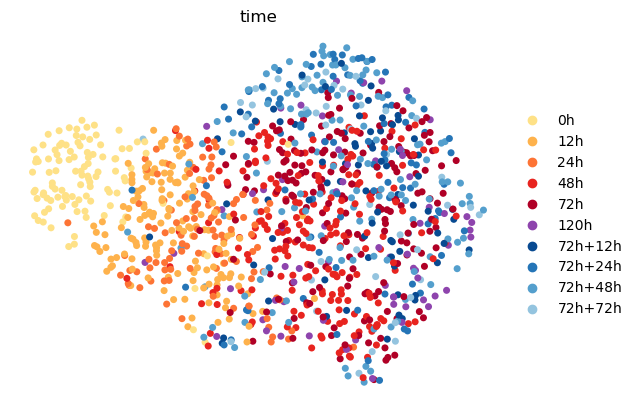

In [37]:
# Annotation UMAP
sc.pl.umap(adata, color=['time'], frameon=False, title=None)

## Gene expression UMAP (requries magic imputation)

UMAPs of gene expression patterns:


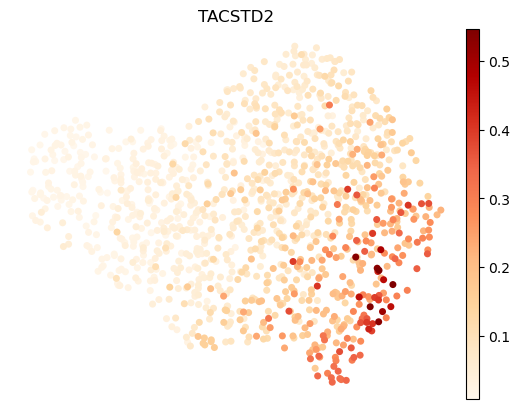

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_3362674/2859259395.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


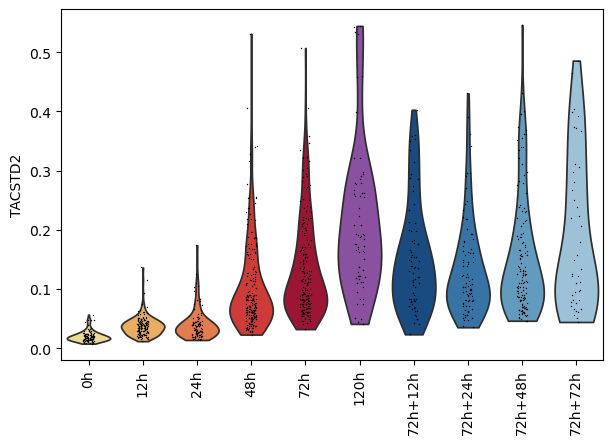

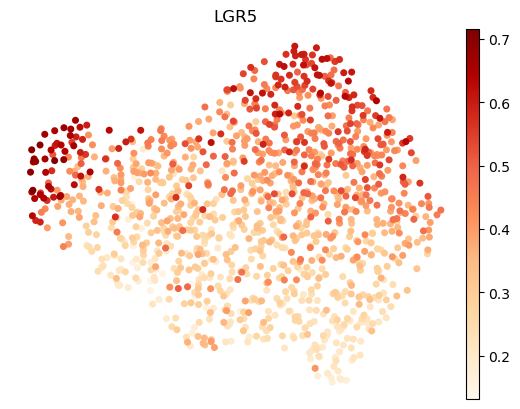

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_3362674/2859259395.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


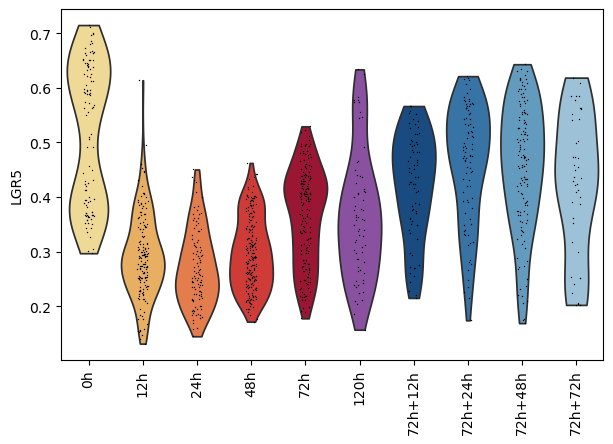

In [39]:
# Features to plot
features = ['TACSTD2', 'LGR5']

# Groupby
groupby = 'time'

# Data layer
layer = 'magic'

# Define plotting parameters
vmax = None
dot_size = 120000 / adata.shape[0]

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot on UMAP
    sc.pl.umap(adata, color=feature, 
               layer=layer, use_raw=False,
               size=dot_size, 
               cmap='OrRd', vmax=vmax, frameon=False)
    plt.tight_layout()
    plt.show()

    # Plot as violin plot
    ax = sc.pl.violin(adata, keys=feature, groupby=groupby, 
                 layer=layer, use_raw=False, rotation=90, show=False)
    if ax.legend_ is not None:
        ax.legend_.set_bbox_to_anchor((1.02, 0.9))

    plt.tight_layout()
    plt.show()